In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="darkgrid")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["figure.figsize"] = (12, 5)

import os
os.makedirs("figures", exist_ok=True)

df = pd.read_csv("../data/processed/listings_enriched.csv", low_memory=False)
cal = pd.read_csv("../data/processed/calendar_clean.csv", low_memory=False)
reviews = pd.read_csv("../data/processed/reviews_clean.csv", low_memory=False)

print(f"Listings: {df.shape}")
print(f"Calendar: {cal.shape}")
print(f"Reviews: {reviews.shape}")

Listings: (28806, 96)
Calendar: (10514202, 10)
Reviews: (585941, 6)


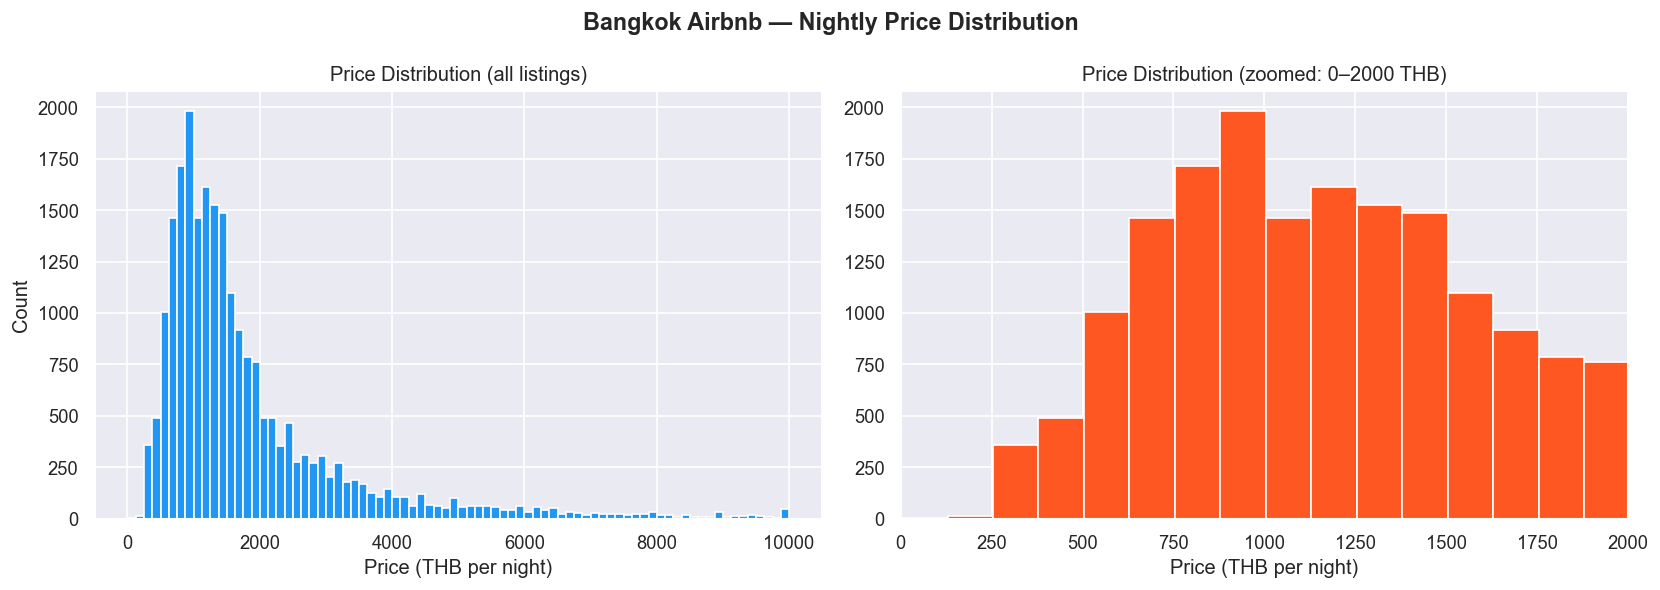

count      23273.000000
mean        2528.749151
std        16473.896035
min            4.000000
25%          923.000000
50%         1379.000000
75%         2207.000000
max      1000000.000000
Name: price, dtype: float64

Median price: 1379.0
Listings over 5000 THB: 1600


In [16]:
# --- Price Distribution ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Remove extreme outliers for visualization
price_filtered = df[df["price"].between(1, 10000)]

axes[0].hist(price_filtered["price"], bins=80, color="#2196F3", edgecolor="white")
axes[0].set_title("Price Distribution (all listings)")
axes[0].set_xlabel("Price (THB per night)")
axes[0].set_ylabel("Count")

axes[1].hist(price_filtered["price"], bins=80, color="#FF5722", edgecolor="white")
axes[1].set_xlim(0, 2000)
axes[1].set_title("Price Distribution (zoomed: 0–2000 THB)")
axes[1].set_xlabel("Price (THB per night)")

plt.suptitle("Bangkok Airbnb — Nightly Price Distribution", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("figures/01_price_distribution.png")
plt.show()

print(df["price"].describe())
print(f"\nMedian price: {df['price'].median()}")
print(f"Listings over 5000 THB: {(df['price'] > 5000).sum()}")

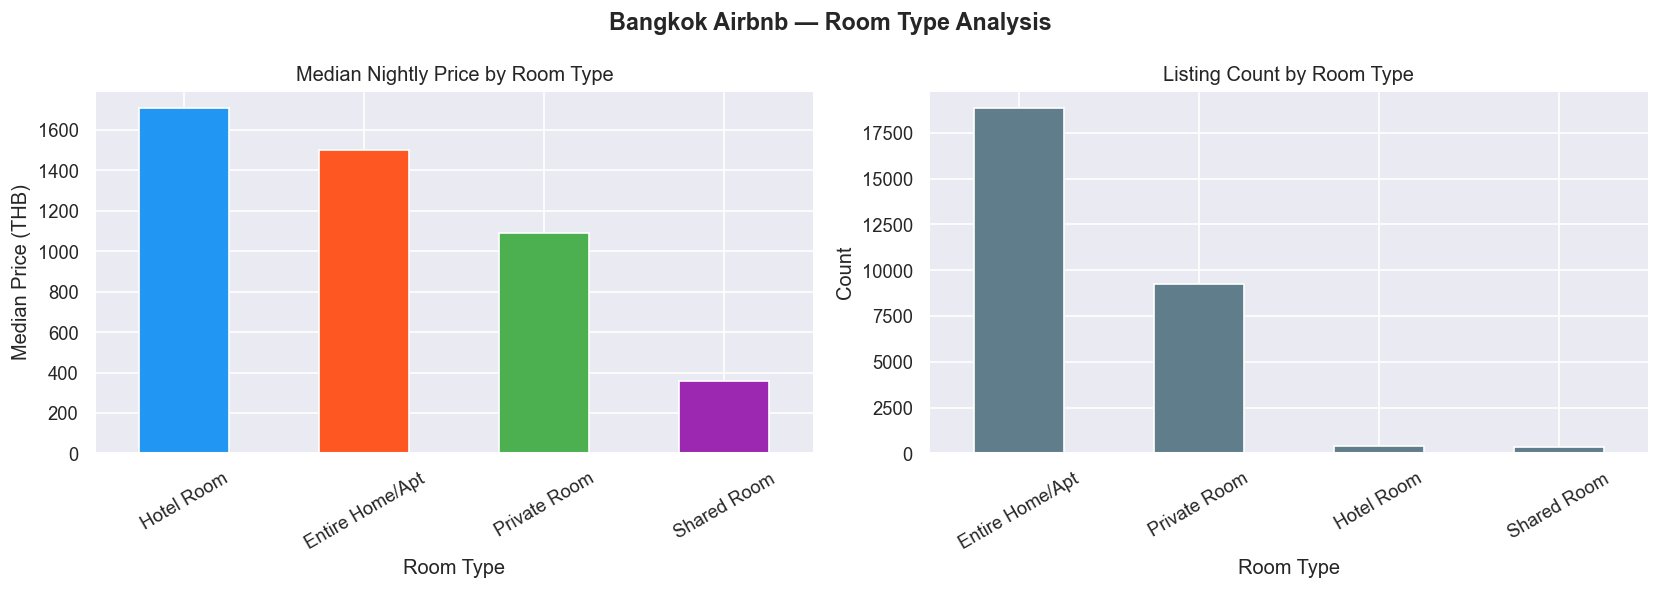

                   count         mean           std    min      25%     50%  \
room_type                                                                     
Entire Home/Apt  16498.0  2767.817069  16770.293236  274.0  1044.00  1500.0   
Hotel Room         198.0  2088.444444   1853.633733  359.0   983.25  1708.5   
Private Room      6263.0  2008.052531  16336.705682    4.0   765.00  1090.0   
Shared Room        314.0   631.171975   1087.223678   34.0   299.00   360.0   

                     75%        max  
room_type                            
Entire Home/Apt  2415.00  1000000.0  
Hotel Room       2556.25    16881.0  
Private Room     1712.00   928572.0  
Shared Room       519.00    11721.0  


In [17]:
# --- Price by Room Type ---
room_price = df.groupby("room_type")["price"].median().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Median price by room type
room_price.plot(kind="bar", ax=axes[0], color=["#2196F3","#FF5722","#4CAF50","#9C27B0"], edgecolor="white")
axes[0].set_title("Median Nightly Price by Room Type")
axes[0].set_xlabel("Room Type")
axes[0].set_ylabel("Median Price (THB)")
axes[0].tick_params(axis="x", rotation=30)

# Listing count by room type
df["room_type"].value_counts().plot(kind="bar", ax=axes[1], color="#607D8B", edgecolor="white")
axes[1].set_title("Listing Count by Room Type")
axes[1].set_xlabel("Room Type")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis="x", rotation=30)

plt.suptitle("Bangkok Airbnb — Room Type Analysis", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("figures/02_room_type_analysis.png")
plt.show()

print(df.groupby("room_type")["price"].describe())

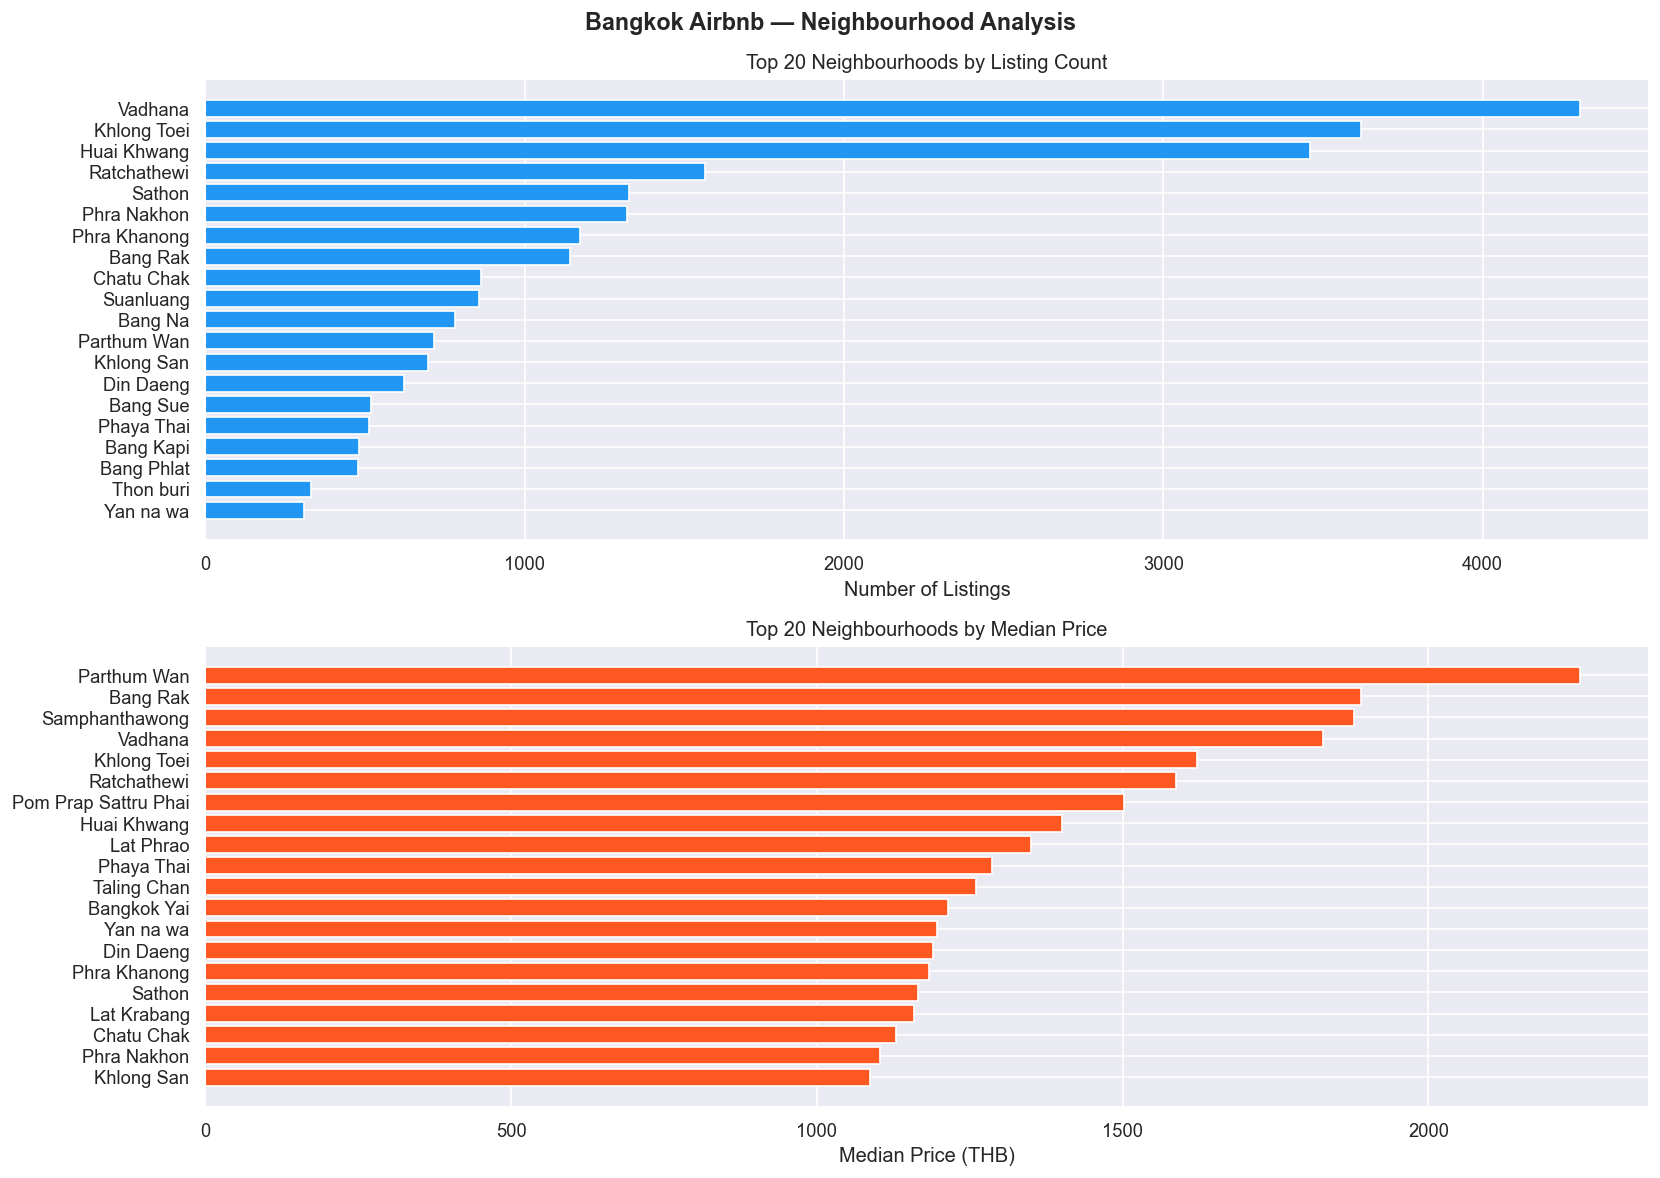

Top 10 by listing count:
   neighbourhood_cleansed  listing_count  median_price  avg_rating
47                Vadhana           4305        1828.0    4.728285
22            Khlong Toei           3620        1622.0    4.677193
18            Huai Khwang           3460        1400.0    4.603040
37            Ratchathewi           1563        1588.0    4.641332
41                 Sathon           1326        1165.0    4.670480
33            Phra Nakhon           1320        1103.0    4.630702
32           Phra Khanong           1172        1184.0    4.712515
8                Bang Rak           1141        1890.0    4.704892
13             Chatu Chak            862        1130.0    4.794845
42              Suanluang            858        1045.0    4.626164


In [18]:
# --- Top Neighbourhoods by Price and Listing Count ---
top_neighbourhoods = df.groupby("neighbourhood_cleansed").agg(
    median_price=("price", "median"),
    listing_count=("id", "count"),
    avg_rating=("review_scores_rating", "mean")
).reset_index().sort_values("listing_count", ascending=False)

top20 = top_neighbourhoods.head(20)

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Top 20 by listing count
axes[0].barh(top20["neighbourhood_cleansed"], top20["listing_count"], color="#2196F3")
axes[0].set_title("Top 20 Neighbourhoods by Listing Count")
axes[0].set_xlabel("Number of Listings")
axes[0].invert_yaxis()

# Top 20 by median price
top20_price = top_neighbourhoods.sort_values("median_price", ascending=False).head(20)
axes[1].barh(top20_price["neighbourhood_cleansed"], top20_price["median_price"], color="#FF5722")
axes[1].set_title("Top 20 Neighbourhoods by Median Price")
axes[1].set_xlabel("Median Price (THB)")
axes[1].invert_yaxis()

plt.suptitle("Bangkok Airbnb — Neighbourhood Analysis", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("figures/03_neighbourhood_analysis.png")
plt.show()

print("Top 10 by listing count:")
print(top20[["neighbourhood_cleansed","listing_count","median_price","avg_rating"]].head(10).to_string())

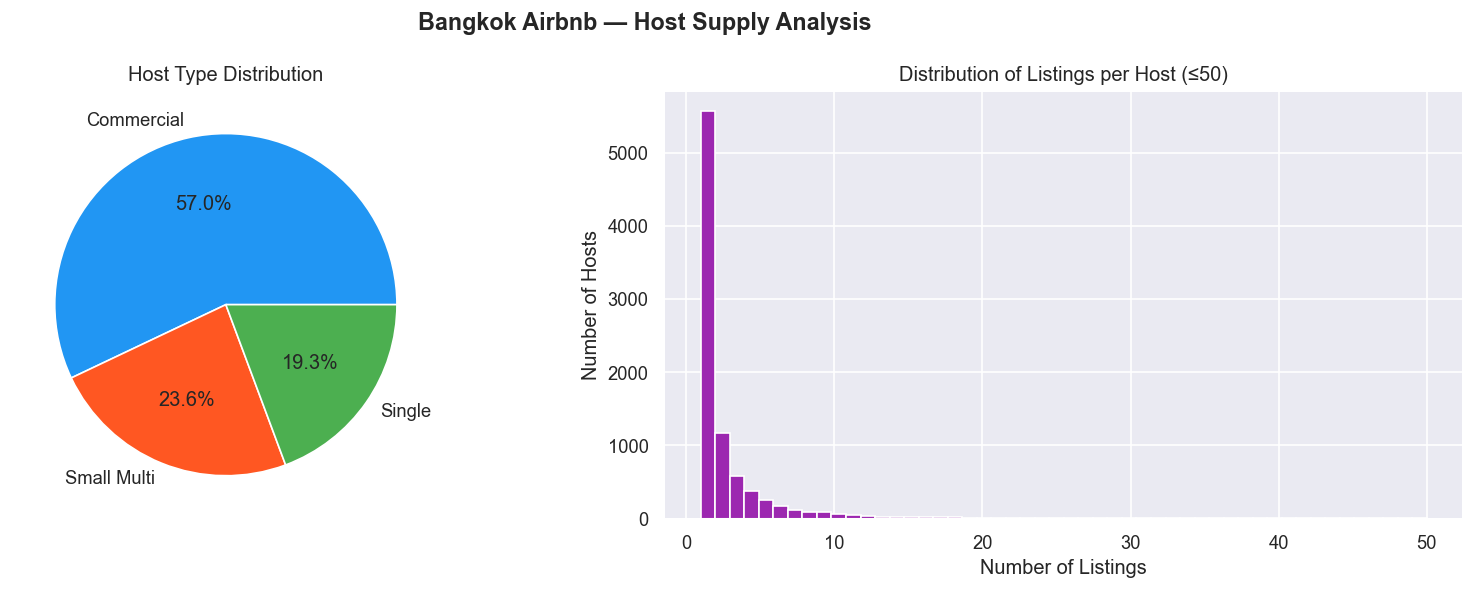

Total hosts: 8874
Single listing hosts: 5565
Commercial hosts (6+ listings): 944
Commercial listings % of market: 57.0%

Top 10 hosts by listing count:
host_id
574804920    243
493412920    193
434168399    182
201677068    174
227771817    141
680424509    135
501920630    117
52161947     110
26736483     109
260093182    109
Name: id, dtype: int64


In [19]:
# --- Host Analysis ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Host type distribution
host_type_counts = df["host_type"].value_counts()
axes[0].pie(host_type_counts.values, labels=host_type_counts.index,
            autopct="%1.1f%%", colors=["#2196F3","#FF5722","#4CAF50"])
axes[0].set_title("Host Type Distribution")

# Listings per host (top hosts)
host_listings = df.groupby("host_id")["id"].count().sort_values(ascending=False)
axes[1].hist(host_listings[host_listings <= 50], bins=50, color="#9C27B0", edgecolor="white")
axes[1].set_title("Distribution of Listings per Host (≤50)")
axes[1].set_xlabel("Number of Listings")
axes[1].set_ylabel("Number of Hosts")

plt.suptitle("Bangkok Airbnb — Host Supply Analysis", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("figures/04_host_analysis.png")
plt.show()

# Market concentration
total_listings = len(df)
commercial_listings = df[df["host_type"] == "Commercial"]["id"].count()
single_hosts = df[df["host_type"] == "Single"]["id"].count()

print(f"Total hosts: {df['host_id'].nunique()}")
print(f"Single listing hosts: {(host_listings == 1).sum()}")
print(f"Commercial hosts (6+ listings): {(host_listings > 5).sum()}")
print(f"Commercial listings % of market: {commercial_listings/total_listings*100:.1f}%")
print(f"\nTop 10 hosts by listing count:")
print(host_listings.head(10))

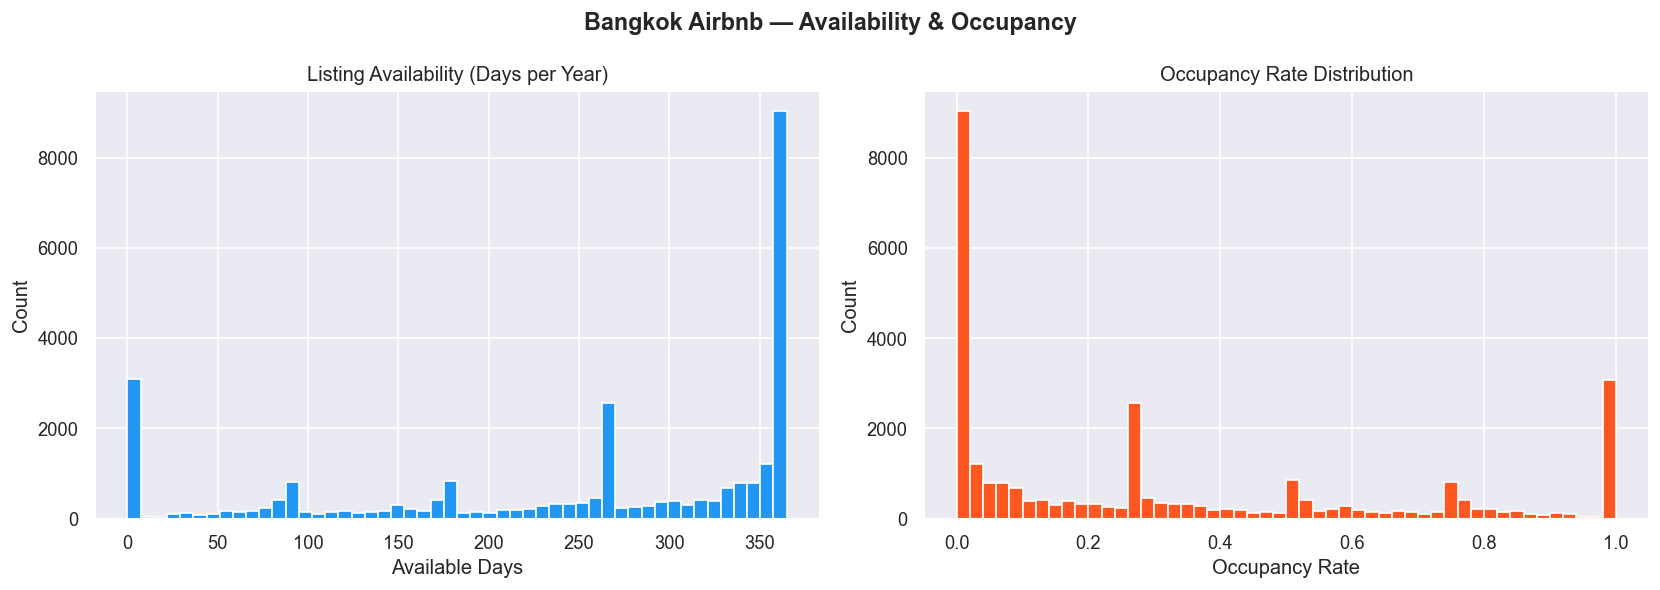

Mean occupancy rate: 31.47%
Median occupancy rate: 20.55%
Mean estimated annual revenue: nan THB
Median estimated annual revenue: nan THB
Listings with revenue data: 0

Occupancy by room type:
room_type
Hotel Room         0.374722
Private Room       0.326964
Entire Home/Apt    0.311084
Shared Room        0.116247
Name: occupancy_rate, dtype: float64


In [20]:
# --- Availability & Occupancy ---

# Recompute avg_calendar_price from calendar
cal_price = cal.groupby("listing_id")["price"].mean().reset_index()
cal_price.columns = ["id", "avg_calendar_price"]
df = df.drop(columns=["avg_calendar_price"], errors="ignore")
df = df.merge(cal_price, on="id", how="left")
df["estimated_annual_revenue"] = df["occupancy_rate"] * df["avg_calendar_price"] * 365

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

avail_filtered = df[df["availability_365"] >= 0]
axes[0].hist(avail_filtered["availability_365"], bins=50, color="#2196F3", edgecolor="white")
axes[0].set_title("Listing Availability (Days per Year)")
axes[0].set_xlabel("Available Days")
axes[0].set_ylabel("Count")

occ_filtered = df[df["occupancy_rate"].between(0, 1)]
axes[1].hist(occ_filtered["occupancy_rate"], bins=50, color="#FF5722", edgecolor="white")
axes[1].set_title("Occupancy Rate Distribution")
axes[1].set_xlabel("Occupancy Rate")
axes[1].set_ylabel("Count")

plt.suptitle("Bangkok Airbnb — Availability & Occupancy", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("figures/05_availability_occupancy.png")
plt.show()

print(f"Mean occupancy rate: {df['occupancy_rate'].mean():.2%}")
print(f"Median occupancy rate: {df['occupancy_rate'].median():.2%}")
print(f"Mean estimated annual revenue: {df['estimated_annual_revenue'].mean():,.0f} THB")
print(f"Median estimated annual revenue: {df['estimated_annual_revenue'].median():,.0f} THB")
print(f"Listings with revenue data: {df['estimated_annual_revenue'].notna().sum()}")

print("\nOccupancy by room type:")
print(df.groupby("room_type")["occupancy_rate"].mean().sort_values(ascending=False))

In [21]:
raw_cal = pd.read_csv("../data/raw/Bangkok/data/calendar.csv", nrows=5)
print(raw_cal[["price", "adjusted_price"]].head())
print(raw_cal.dtypes)

   price  adjusted_price
0    NaN             NaN
1    NaN             NaN
2    NaN             NaN
3    NaN             NaN
4    NaN             NaN
listing_id          int64
date               object
available          object
price             float64
adjusted_price    float64
minimum_nights      int64
maximum_nights      int64
dtype: object


In [22]:
# Use listing price + availability as revenue proxy
df["occupancy_rate"] = 1 - (df["availability_365"] / 365)
df["estimated_annual_revenue"] = df["price"] * (365 - df["availability_365"])

print(f"Mean occupancy rate: {df['occupancy_rate'].mean():.2%}")
print(f"Median occupancy rate: {df['occupancy_rate'].median():.2%}")
print(f"Mean estimated annual revenue: {df['estimated_annual_revenue'].mean():,.0f} THB")
print(f"Median estimated annual revenue: {df['estimated_annual_revenue'].median():,.0f} THB")
print(f"Listings with revenue data: {df['estimated_annual_revenue'].notna().sum()}")

print("\nOccupancy proxy by room type:")
print(df.groupby("room_type")["occupancy_rate"].mean().sort_values(ascending=False))

Mean occupancy rate: 31.49%
Median occupancy rate: 20.55%
Mean estimated annual revenue: 203,274 THB
Median estimated annual revenue: 61,848 THB
Listings with revenue data: 23273

Occupancy proxy by room type:
room_type
Hotel Room         0.378840
Private Room       0.326995
Entire Home/Apt    0.311411
Shared Room        0.116250
Name: occupancy_rate, dtype: float64


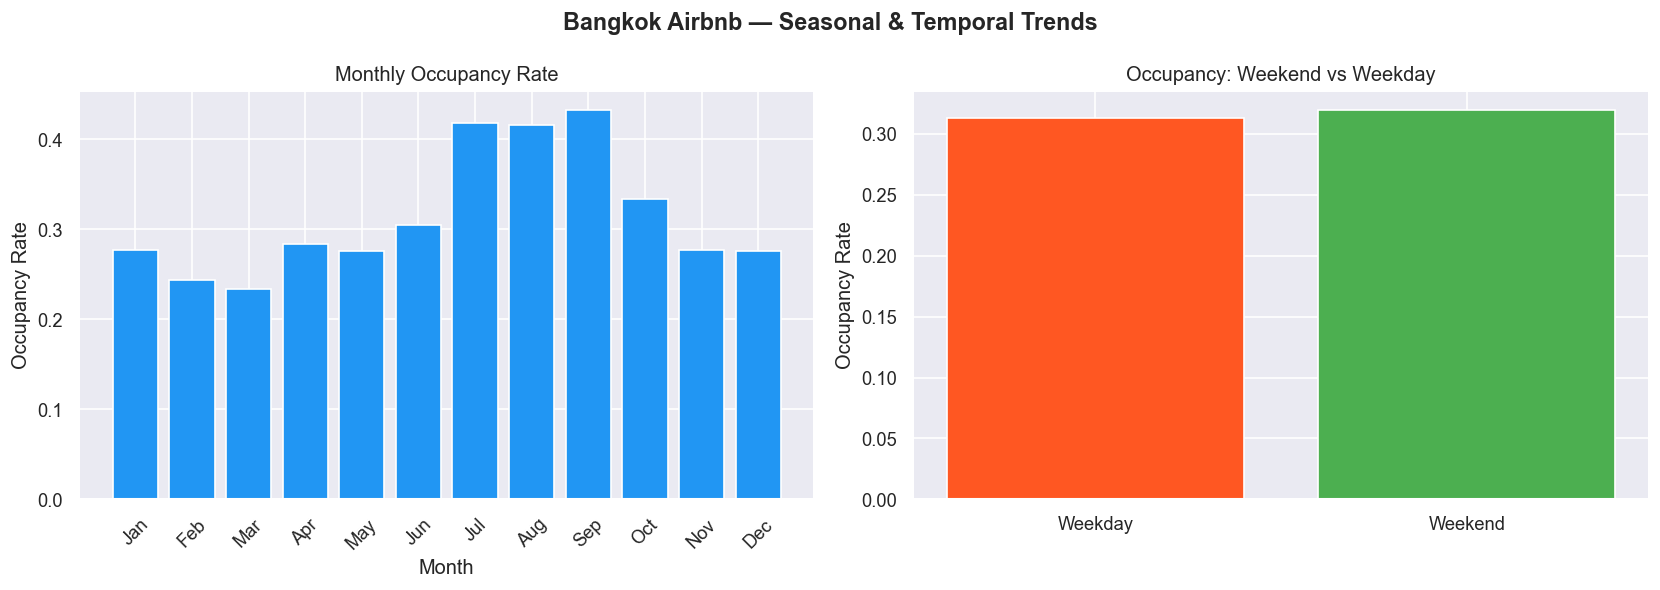

Monthly occupancy:
   month_name  occupancy_rate
0         Jan        0.276692
1         Feb        0.244081
2         Mar        0.233513
3         Apr        0.283400
4         May        0.275513
5         Jun        0.304655
6         Jul        0.417635
7         Aug        0.415671
8         Sep        0.432196
9         Oct        0.333863
10        Nov        0.277357
11        Dec        0.275778

Weekend occupancy: 31.94%
Weekday occupancy: 31.28%


In [23]:
# --- Seasonal Trends from Calendar ---
cal["date"] = pd.to_datetime(cal["date"])
cal["month"] = cal["date"].dt.month
cal["month_name"] = cal["date"].dt.strftime("%b")
cal["day_of_week"] = cal["date"].dt.day_name()
cal["is_weekend"] = cal["day_of_week"].isin(["Saturday", "Sunday"])

# Monthly availability rate
monthly_avail = cal.groupby("month")["available"].apply(
    lambda x: (x == True).sum() / len(x)
).reset_index()
monthly_avail.columns = ["month", "availability_rate"]
monthly_avail["occupancy_rate"] = 1 - monthly_avail["availability_rate"]

month_names = {1:"Jan",2:"Feb",3:"Mar",4:"Apr",5:"May",6:"Jun",
               7:"Jul",8:"Aug",9:"Sep",10:"Oct",11:"Nov",12:"Dec"}
monthly_avail["month_name"] = monthly_avail["month"].map(month_names)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(monthly_avail["month_name"], monthly_avail["occupancy_rate"],
            color="#2196F3", edgecolor="white")
axes[0].set_title("Monthly Occupancy Rate")
axes[0].set_xlabel("Month")
axes[0].set_ylabel("Occupancy Rate")
axes[0].tick_params(axis="x", rotation=45)

# Weekend vs weekday occupancy
weekend_occ = cal.groupby("is_weekend")["available"].apply(
    lambda x: (x == False).sum() / len(x)
).reset_index()
weekend_occ["label"] = weekend_occ["is_weekend"].map({True: "Weekend", False: "Weekday"})
axes[1].bar(weekend_occ["label"], weekend_occ["available"],
            color=["#FF5722","#4CAF50"], edgecolor="white")
axes[1].set_title("Occupancy: Weekend vs Weekday")
axes[1].set_ylabel("Occupancy Rate")

plt.suptitle("Bangkok Airbnb — Seasonal & Temporal Trends", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("figures/06_seasonal_trends.png")
plt.show()

print("Monthly occupancy:")
print(monthly_avail[["month_name","occupancy_rate"]].to_string())
print(f"\nWeekend occupancy: {weekend_occ[weekend_occ['is_weekend']==True]['available'].values[0]:.2%}")
print(f"Weekday occupancy: {weekend_occ[weekend_occ['is_weekend']==False]['available'].values[0]:.2%}")

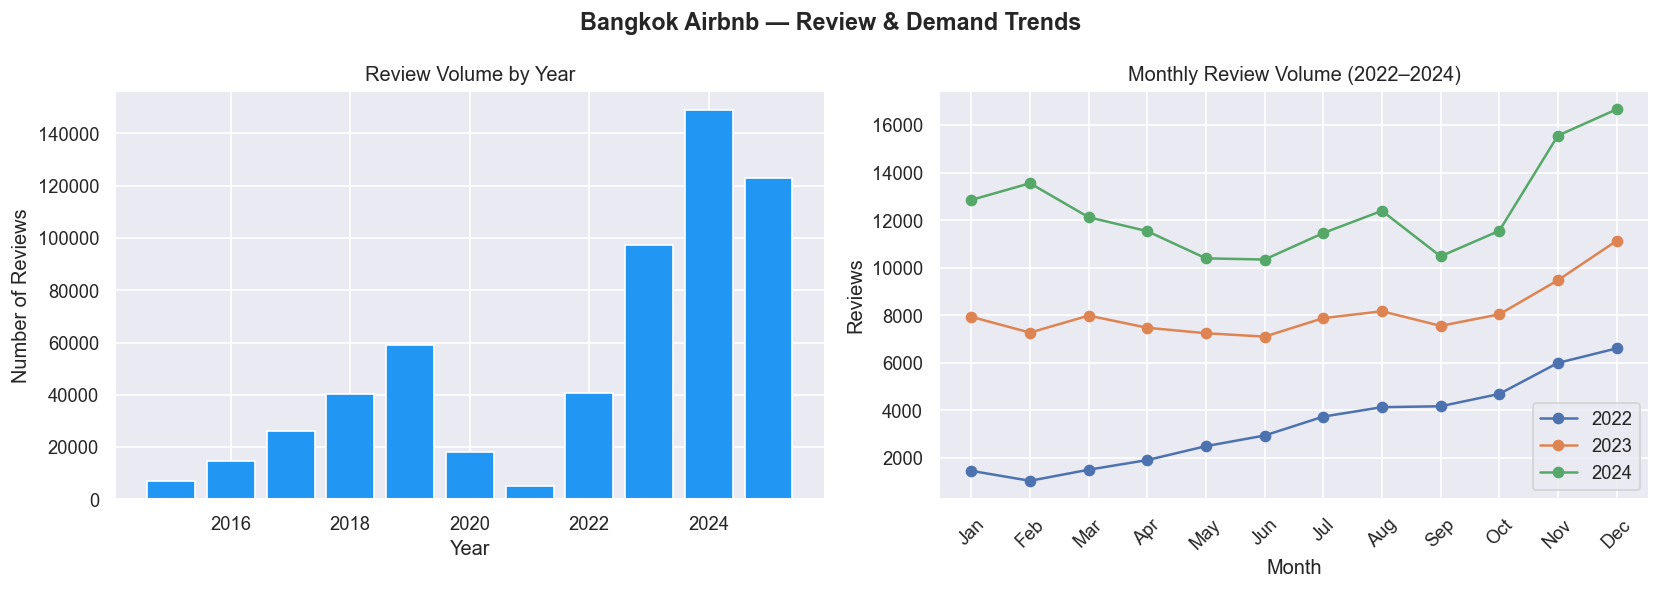

Reviews by year:
year
2015.0      7046
2016.0     14811
2017.0     26026
2018.0     40304
2019.0     59010
2020.0     18014
2021.0      5171
2022.0     40567
2023.0     97184
2024.0    148869
2025.0    122916
dtype: int64


In [24]:
# --- Review Trends ---
import pandas as pd

reviews["date"] = pd.to_datetime(reviews["date"])
reviews["year"] = reviews["date"].dt.year
reviews["month"] = reviews["date"].dt.month
reviews["year_month"] = reviews["date"].dt.to_period("M")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Review volume by year
yearly = reviews[reviews["year"].between(2015, 2025)].groupby("year").size()
axes[0].bar(yearly.index, yearly.values, color="#2196F3", edgecolor="white")
axes[0].set_title("Review Volume by Year")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Number of Reviews")

# Review volume by month (seasonality)
monthly_reviews = reviews[reviews["year"].between(2022, 2025)].groupby(
    ["year", "month"]
).size().reset_index(name="count")
for year in [2022, 2023, 2024]:
    subset = monthly_reviews[monthly_reviews["year"] == year]
    axes[1].plot(subset["month"], subset["count"], marker="o", label=str(year))
axes[1].set_title("Monthly Review Volume (2022–2024)")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Reviews")
axes[1].legend()
axes[1].set_xticks(range(1, 13))
axes[1].set_xticklabels(["Jan","Feb","Mar","Apr","May","Jun",
                          "Jul","Aug","Sep","Oct","Nov","Dec"], rotation=45)

plt.suptitle("Bangkok Airbnb — Review & Demand Trends", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("figures/07_review_trends.png")
plt.show()

print("Reviews by year:")
print(yearly)

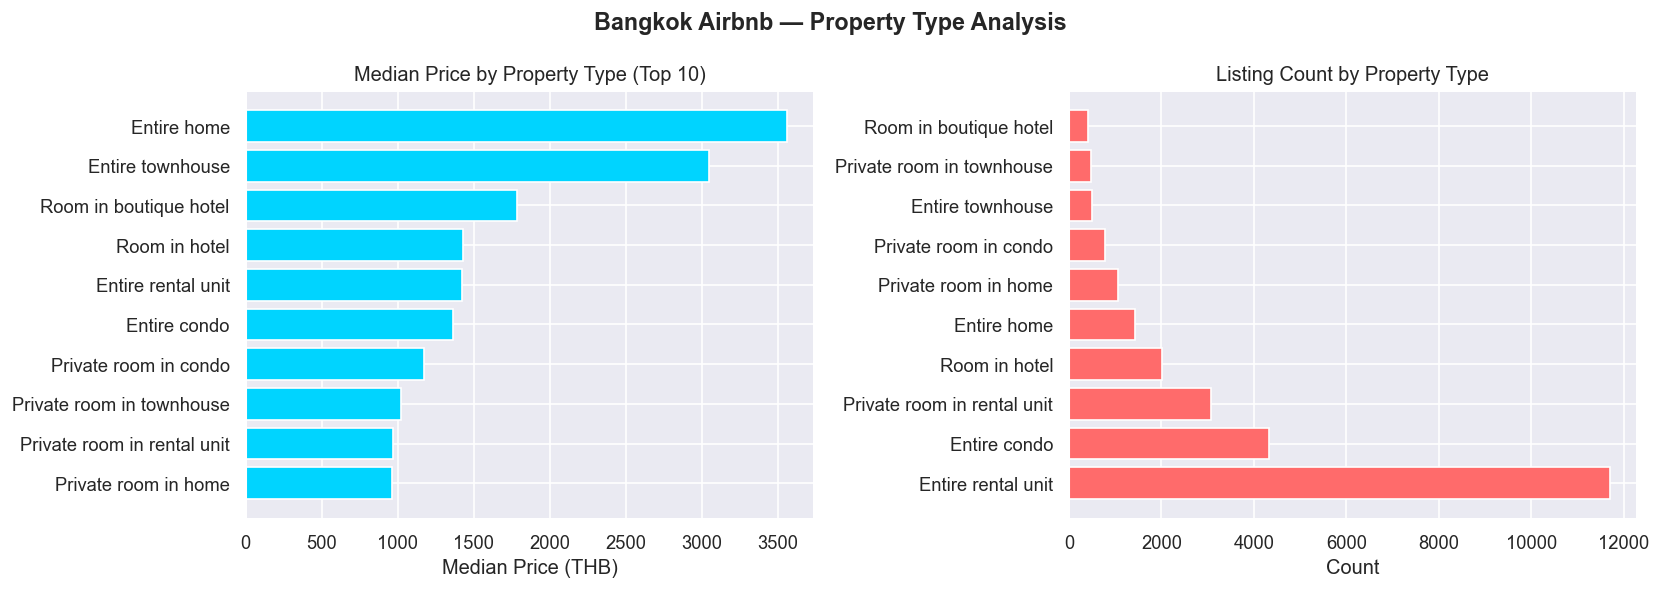

                             median  count
property_type                             
Entire home                  3556.5   1268
Entire townhouse             3049.5    444
Room in boutique hotel       1781.0    277
Room in hotel                1430.0   1213
Entire rental unit           1425.0  10335
Entire condo                 1360.0   3657
Private room in condo        1170.0    485
Private room in townhouse    1023.0    401
Private room in rental unit   966.5   2226
Private room in home          960.0    827


In [25]:
# --- Price by Property Type ---
top_property = df["property_type"].value_counts().head(10).index
prop_df = df[df["property_type"].isin(top_property)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

prop_price = prop_df.groupby("property_type")["price"].median().sort_values(ascending=True)
axes[0].barh(prop_price.index, prop_price.values, color="#00d4ff")
axes[0].set_title("Median Price by Property Type (Top 10)")
axes[0].set_xlabel("Median Price (THB)")

prop_count = prop_df["property_type"].value_counts()
axes[1].barh(prop_count.index, prop_count.values, color="#ff6b6b")
axes[1].set_title("Listing Count by Property Type")
axes[1].set_xlabel("Count")

plt.suptitle("Bangkok Airbnb — Property Type Analysis", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("figures/18_property_type.png")
plt.show()

print(prop_df.groupby("property_type")["price"].agg(["median","count"]).sort_values("median", ascending=False).head(10))

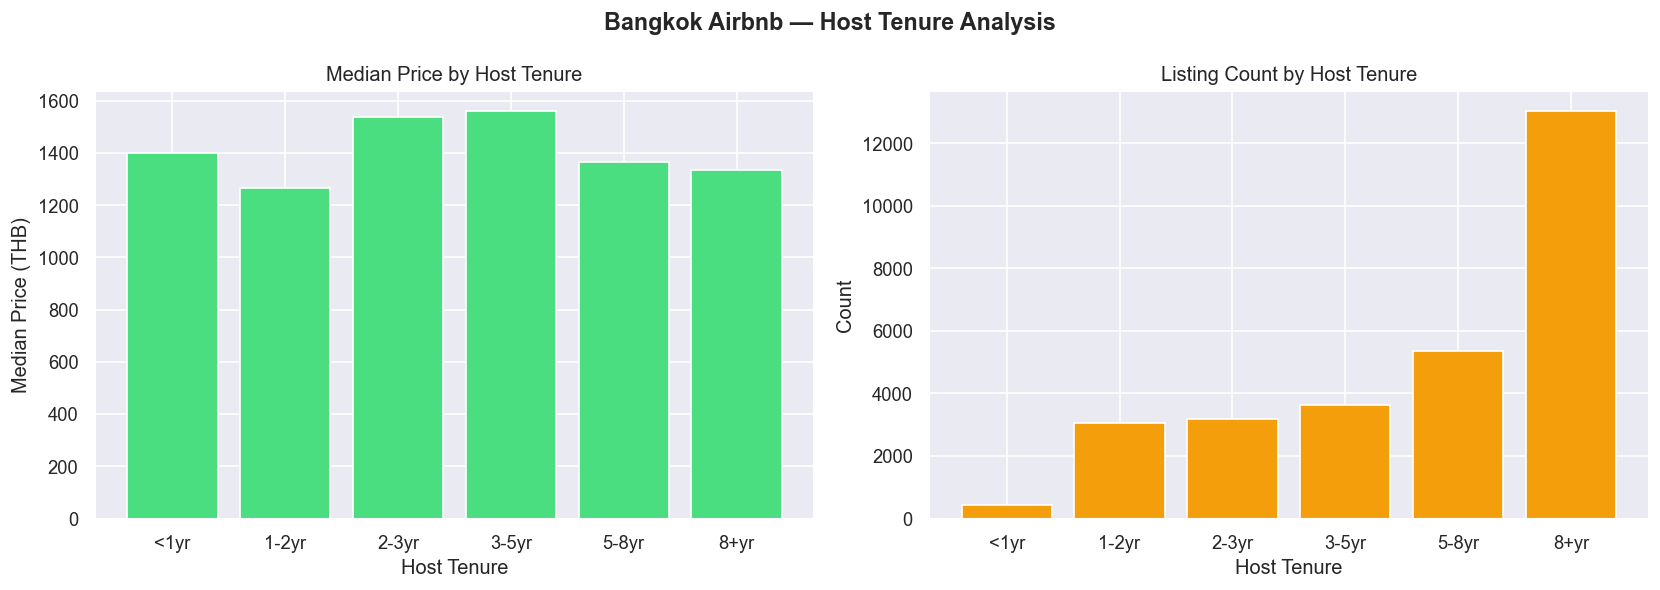

              median  count
tenure_group               
<1yr          1400.0    422
1-2yr         1264.0   2729
2-3yr         1536.0   2762
3-5yr         1560.0   3031
5-8yr         1364.5   3946
8+yr          1333.0  10317


In [26]:
# --- Host Tenure vs Price ---
df["host_since"] = pd.to_datetime(df["host_since"], errors="coerce")
df["host_tenure_years"] = ((pd.Timestamp.now() - df["host_since"]).dt.days / 365).round(1)

tenure_bins = [0, 1, 2, 3, 5, 8, 15]
tenure_labels = ["<1yr", "1-2yr", "2-3yr", "3-5yr", "5-8yr", "8+yr"]
df["tenure_group"] = pd.cut(df["host_tenure_years"], bins=tenure_bins, labels=tenure_labels)

tenure_price = df.groupby("tenure_group", observed=True)["price"].median().reset_index()
tenure_count = df.groupby("tenure_group", observed=True)["id"].count().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(tenure_price["tenure_group"].astype(str), tenure_price["price"],
            color="#4ade80", edgecolor="white")
axes[0].set_title("Median Price by Host Tenure")
axes[0].set_xlabel("Host Tenure")
axes[0].set_ylabel("Median Price (THB)")

axes[1].bar(tenure_count["tenure_group"].astype(str), tenure_count["id"],
            color="#f59e0b", edgecolor="white")
axes[1].set_title("Listing Count by Host Tenure")
axes[1].set_xlabel("Host Tenure")
axes[1].set_ylabel("Count")

plt.suptitle("Bangkok Airbnb — Host Tenure Analysis", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("figures/19_host_tenure.png")
plt.show()

print(df.groupby("tenure_group", observed=True)["price"].agg(["median","count"]))

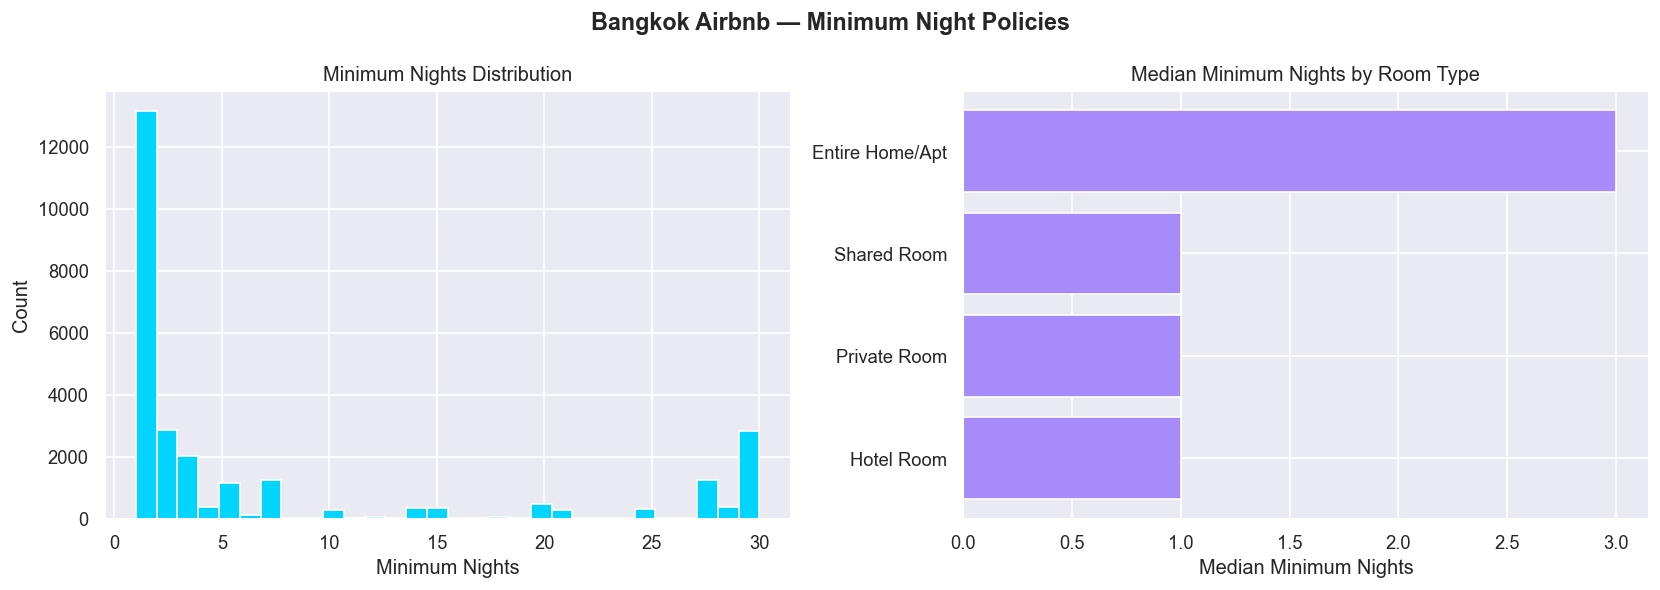

Minimum nights distribution:
count    28806.000000
mean        14.107373
std         43.243299
min          1.000000
25%          1.000000
50%          2.000000
75%         14.000000
max       1115.000000
Name: minimum_nights, dtype: float64

1-night minimum: 45.7%
7+ night minimum: 31.8%
30+ night minimum: 14.1%

Median minimum nights by room type:
room_type
Entire Home/Apt    3.0
Hotel Room         1.0
Private Room       1.0
Shared Room        1.0
Name: minimum_nights, dtype: float64


In [27]:
# --- Minimum Nights Analysis ---
min_nights = df[df["minimum_nights"] <= 30]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(min_nights["minimum_nights"], bins=30, 
             color="#00d4ff", edgecolor="white")
axes[0].set_title("Minimum Nights Distribution")
axes[0].set_xlabel("Minimum Nights")
axes[0].set_ylabel("Count")

# Min nights by room type
min_room = df.groupby("room_type")["minimum_nights"].median().sort_values()
axes[1].barh(min_room.index, min_room.values, color="#a78bfa")
axes[1].set_title("Median Minimum Nights by Room Type")
axes[1].set_xlabel("Median Minimum Nights")

plt.suptitle("Bangkok Airbnb — Minimum Night Policies", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("figures/20_minimum_nights.png")
plt.show()

print("Minimum nights distribution:")
print(df["minimum_nights"].describe())
print(f"\n1-night minimum: {(df['minimum_nights']==1).mean():.1%}")
print(f"7+ night minimum: {(df['minimum_nights']>=7).mean():.1%}")
print(f"30+ night minimum: {(df['minimum_nights']>=30).mean():.1%}")
print("\nMedian minimum nights by room type:")
print(df.groupby("room_type")["minimum_nights"].median())

High reviews (>50) + Low score (<4.0): 0 listings
High reviews (>50) + Excellent score (≥4.8): 1724 listings

--- Review Score Sub-Dimensions ---
review_scores_value            4.646765
review_scores_location         4.659068
review_scores_cleanliness      4.681701
review_scores_accuracy         4.721541
review_scores_checkin          4.764034
review_scores_communication    4.780835
dtype: float64


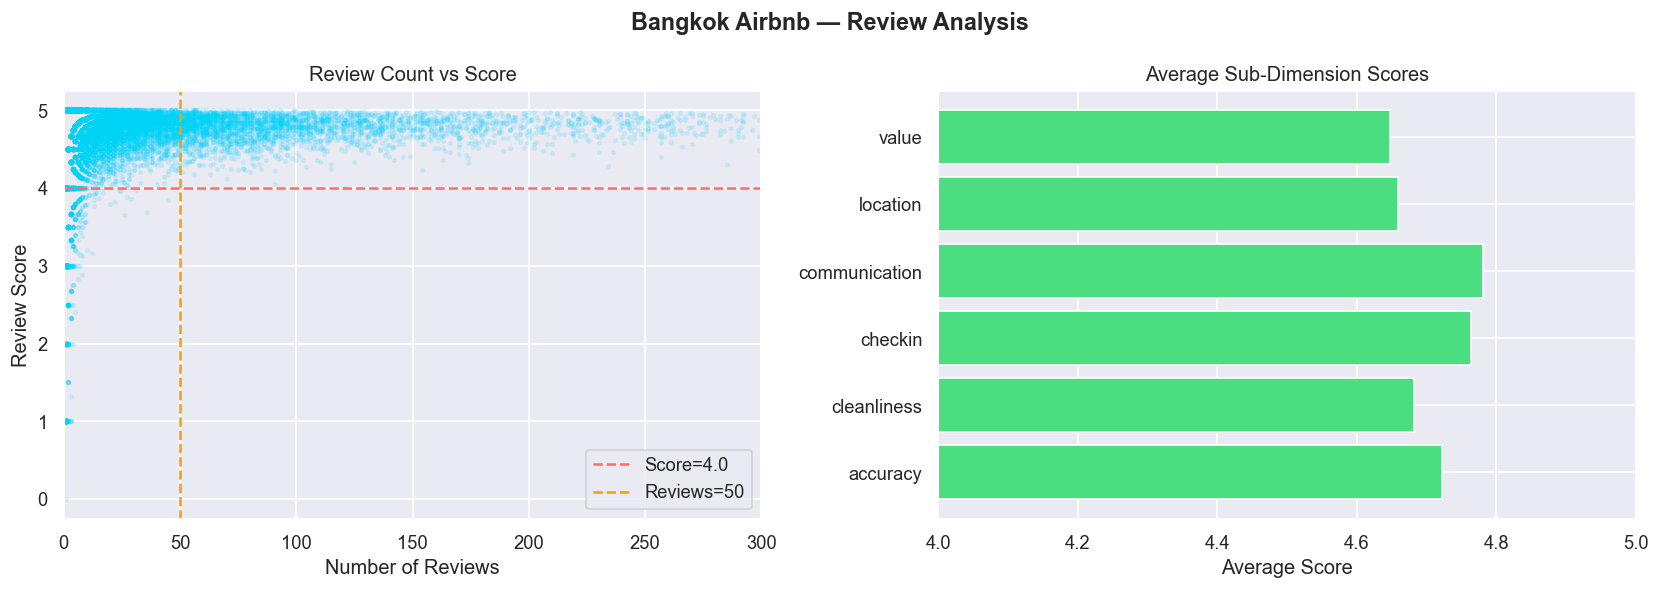

In [28]:
# --- High Review Count but Low Score Listings ---
df_rated = df[df["review_scores_rating"].notna() & df["number_of_reviews"].notna()]

# High reviews (>50) but low score (<4.0)
problematic = df_rated[
    (df_rated["number_of_reviews"] > 50) & 
    (df_rated["review_scores_rating"] < 4.0)
].copy()

# High reviews + high score (benchmark)
excellent = df_rated[
    (df_rated["number_of_reviews"] > 50) & 
    (df_rated["review_scores_rating"] >= 4.8)
].copy()

print(f"High reviews (>50) + Low score (<4.0): {len(problematic)} listings")
print(f"High reviews (>50) + Excellent score (≥4.8): {len(excellent)} listings")

if len(problematic) > 0:
    print("\nProblematic listing characteristics:")
    print(problematic[["room_type","price","neighbourhood_cleansed",
                        "number_of_reviews","review_scores_rating",
                        "host_is_superhost"]].describe())
    
    print("\nRoom type breakdown of problematic listings:")
    print(problematic["room_type"].value_counts())
    
    print("\nNeighbourhood breakdown:")
    print(problematic["neighbourhood_cleansed"].value_counts().head(5))

# Review sub-dimensions
print("\n--- Review Score Sub-Dimensions ---")
sub_dims = ["review_scores_accuracy", "review_scores_cleanliness",
            "review_scores_checkin", "review_scores_communication",
            "review_scores_location", "review_scores_value"]

existing_dims = [c for c in sub_dims if c in df.columns]
sub_scores = df[existing_dims].mean().sort_values()
print(sub_scores)

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter: reviews vs rating
axes[0].scatter(df_rated["number_of_reviews"], 
                df_rated["review_scores_rating"],
                alpha=0.1, s=5, color="#00d4ff")
axes[0].axhline(4.0, color="#ff6b6b", linestyle="--", label="Score=4.0")
axes[0].axvline(50, color="#f59e0b", linestyle="--", label="Reviews=50")
axes[0].set_title("Review Count vs Score")
axes[0].set_xlabel("Number of Reviews")
axes[0].set_ylabel("Review Score")
axes[0].set_xlim(0, 300)
axes[0].legend()

# Sub-dimension scores
axes[1].barh([c.replace("review_scores_","") for c in existing_dims],
             df[existing_dims].mean().values, color="#4ade80")
axes[1].set_title("Average Sub-Dimension Scores")
axes[1].set_xlabel("Average Score")
axes[1].set_xlim(4.0, 5.0)

plt.suptitle("Bangkok Airbnb — Review Analysis", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("figures/21_review_analysis.png")
plt.show()

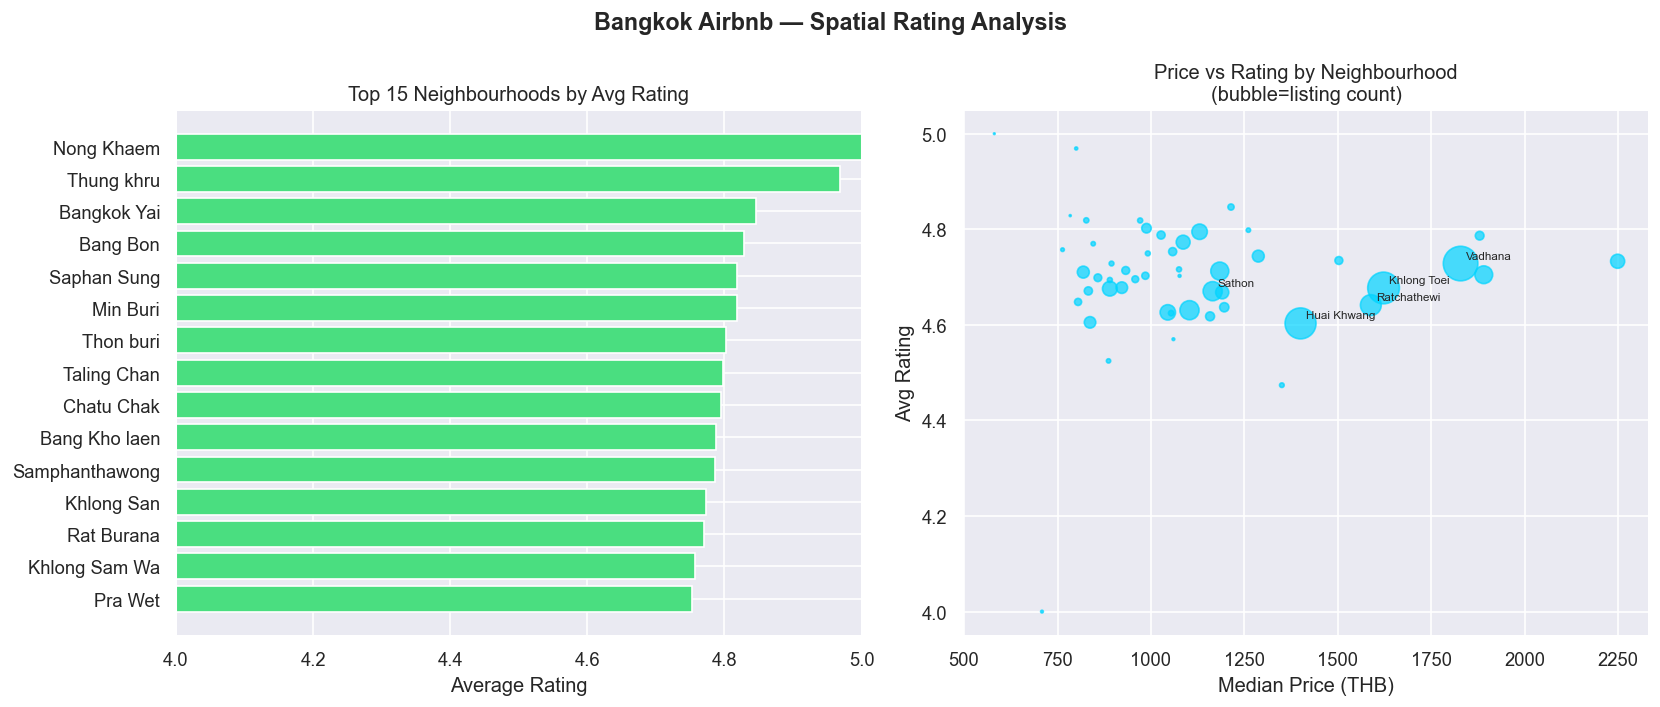

Top 10 neighbourhoods by rating:
   neighbourhood_cleansed  avg_rating  listing_count  median_price
28             Nong Khaem    5.000000             11         581.0
46             Thung khru    4.969091             34         800.0
11            Bangkok Yai    4.846548            139        1214.0
0                Bang Bon    4.828571             15         784.0
40            Saphan Sung    4.818730             97         827.0
26               Min Buri    4.818421             93         971.0
45              Thon buri    4.802222            329         988.0
43            Taling Chan    4.798182             69        1260.5
13             Chatu Chak    4.794845            862        1130.0
4           Bang Kho laen    4.787887            236        1027.0


In [29]:
# --- Spatial Review Score by Neighbourhood ---
nb_ratings = df.groupby("neighbourhood_cleansed").agg(
    avg_rating=("review_scores_rating", "mean"),
    listing_count=("id", "count"),
    median_price=("price", "median")
).reset_index().dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Rating by neighbourhood
nb_top = nb_ratings.sort_values("avg_rating", ascending=True).tail(15)
axes[0].barh(nb_top["neighbourhood_cleansed"], nb_top["avg_rating"],
             color="#4ade80")
axes[0].set_title("Top 15 Neighbourhoods by Avg Rating")
axes[0].set_xlabel("Average Rating")
axes[0].set_xlim(4.0, 5.0)

# Price vs rating scatter
axes[1].scatter(nb_ratings["median_price"], nb_ratings["avg_rating"],
                s=nb_ratings["listing_count"]/10,
                color="#00d4ff", alpha=0.7)
for _, row in nb_ratings.nlargest(5, "listing_count").iterrows():
    axes[1].annotate(row["neighbourhood_cleansed"],
                     (row["median_price"], row["avg_rating"]),
                     fontsize=7, xytext=(3,3),
                     textcoords="offset points")
axes[1].set_title("Price vs Rating by Neighbourhood\n(bubble=listing count)")
axes[1].set_xlabel("Median Price (THB)")
axes[1].set_ylabel("Avg Rating")

plt.suptitle("Bangkok Airbnb — Spatial Rating Analysis", 
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("figures/22_spatial_ratings.png")
plt.show()

print("Top 10 neighbourhoods by rating:")
print(nb_ratings.sort_values("avg_rating", ascending=False)[
    ["neighbourhood_cleansed","avg_rating","listing_count","median_price"]
].head(10).to_string())